<a href="https://colab.research.google.com/github/thanosleggis/Thesis/blob/main/notebooks/ACTNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import scipy.io as sio
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Διαδρομή αρχείου (όπως το βρήκε πριν)
mat_path = '/content/DREAMER_extracted/DREAMER.mat'

def load_dreamer_final(path):
    print(f"📂 Άνοιγμα αρχείου: {path}")
    try:
        raw = sio.loadmat(path)
        data_struct = raw['DREAMER'][0, 0]['Data']

        X_list = []
        y_list = []

        print("🔍 Εξερεύνηση δομής για τον 1ο συμμετέχοντα...")
        # Παίρνουμε τα δεδομένα του 1ου συμμετέχοντα για έλεγχο
        sub0 = data_struct[0, 0]
        eeg_struct = sub0['EEG'][0, 0]

        # --- DEBUG: ΤΥΠΩΣΕ ΤΑ ΚΛΕΙΔΙΑ ---
        print(f"🔑 Τα πεδία μέσα στο 'EEG' είναι: {eeg_struct.dtype.names}")

        # Επιλογή κλειδιού (Συνήθως είναι 'stimuli' στο DREAMER)
        target_key = 'stimuli' if 'stimuli' in eeg_struct.dtype.names else 'Signals'

        if target_key not in eeg_struct.dtype.names:
            print("❌ Δεν βρέθηκε ούτε 'stimuli' ούτε 'Signals'. Έλεγξε τα κλειδιά παραπάνω.")
            return None, None

        print(f"✅ Χρήση του πεδίου: '{target_key}'")

        # --- LOOP ΑΝΑΓΝΩΣΗΣ ---
        for sub in range(23):
            sub_data = data_struct[0, sub]

            # 1. Labels
            valence = sub_data['ScoreValence'][0, 0] # Array (18, 1)

            # 2. EEG Signals
            # To EEG -> stimuli είναι cell array (18, 1)
            eeg_data = sub_data['EEG'][0, 0][target_key][0, 0]

            for trial in range(18):
                # Label
                val_score = valence[trial, 0]
                label = 1 if val_score >= 3 else 0

                # Signal
                # Το signal είναι μέσα στο cell array
                signal = eeg_data[trial, 0] # (Timepoints, 14)

                # Check dimensions & Crop
                if signal.shape[0] > 128:
                    seg = signal[:128, :].T # (14, 128)
                    X_list.append(seg)
                    y_list.append(label)

        X = np.array(X_list, dtype=np.float32)[:, np.newaxis, :, :]
        y = np.array(y_list, dtype=np.int64)

        print(f"🎉 ΕΠΙΤΥΧΙΑ! Φορτώθηκαν {len(y)} δείγματα.")
        return torch.tensor(X), torch.tensor(y)

    except Exception as e:
        print(f"❌ Σφάλμα: {e}")
        return None, None

# --- ΕΚΤΕΛΕΣΗ ---
X_data, y_data = load_dreamer_final(mat_path)

if X_data is not None:
    # ACTNN Model Setup
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"🚀 Training on {device}")

    class ACTNN(nn.Module):
        def __init__(self):
            super().__init__()
            self.cnn = nn.Sequential(
                nn.Conv2d(1, 16, (14, 1)), nn.BatchNorm2d(16), nn.ELU(),
                nn.Conv2d(16, 32, (1, 10), stride=2), nn.BatchNorm2d(32), nn.ELU()
            )
            self.transformer = nn.TransformerEncoder(
                nn.TransformerEncoderLayer(d_model=32, nhead=4, batch_first=True), num_layers=2)
            self.fc = nn.Linear(32, 2)
            self.attn = nn.Linear(32, 1)

        def forward(self, x):
            x = self.cnn(x).squeeze(2).permute(0, 2, 1)
            x = self.transformer(x)
            w = torch.softmax(self.attn(x), dim=1)
            return self.fc((x * w).sum(dim=1))

    model = ACTNN().to(device)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    loader = DataLoader(TensorDataset(X_data, y_data), batch_size=32, shuffle=True)

    # Train
    for epoch in range(10):
        model.train()
        acc = 0
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(X)
            loss = nn.CrossEntropyLoss()(out, y)
            loss.backward()
            optimizer.step()
            acc += (out.argmax(1) == y).sum().item()
        print(f"Epoch {epoch+1} | Acc: {acc/len(X_data):.2%}")

📂 Άνοιγμα αρχείου: /content/DREAMER_extracted/DREAMER.mat
❌ Σφάλμα: [Errno 2] No such file or directory: '/content/DREAMER_extracted/DREAMER.mat'


In [ ]:
import os
import zipfile
import scipy.io as sio
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from google.colab import drive

# --- ΒΗΜΑ 1: Σύνδεση Drive & Εντοπισμός ZIP ---
print("🔌 Σύνδεση με Google Drive...")
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')

# Ψάχνουμε το zip
zip_paths = [
    '/content/DREAMER.zip',                  # Αν το ανέβασες τοπικά
    '/content/drive/MyDrive/DREAMER.zip'     # Αν είναι στο Drive (Προτείνεται)
]

target_zip = None
for p in zip_paths:
    if os.path.exists(p):
        target_zip = p
        print(f"✅ Βρέθηκε το ZIP: {p}")
        break

if target_zip is None:
    print("\n❌ ΣΦΑΛΜΑ: Δεν βρέθηκε το DREAMER.zip!")
    print("👉 Ανέβασε το ξανά στα Files ή βεβαιώσου ότι είναι στο MyDrive.")
    # Stop execution manually here if needed
else:
    # --- ΒΗΜΑ 2: Αποσυμπίεση ---
    extract_path = '/content/DREAMER_extracted'
    if not os.path.exists(extract_path):
        print("⏳ Ξεκινάει η αποσυμπίεση...")
        with zipfile.ZipFile(target_zip, 'r') as zip_ref:
            zip_ref.extractall(extract_path)
        print("✅ Η αποσυμπίεση ολοκληρώθηκε.")
    else:
        print("✅ Ο φάκελος υπάρχει ήδη.")

    # Βρίσκουμε το .mat μέσα στον φάκελο
    mat_path = None
    for root, dirs, files in os.walk(extract_path):
        for file in files:
            if file.endswith('.mat') and 'DREAMER' in file:
                mat_path = os.path.join(root, file)
                break
        if mat_path: break

    # --- ΒΗΜΑ 3: Φόρτωση με Augmentation ---
    def load_dreamer_gpu(path):
        print(f"🔄 Φόρτωση δεδομένων από: {path}")
        try:
            raw = sio.loadmat(path)
            data_struct = raw['DREAMER'][0, 0]['Data']
            X_list, y_list = [], []

            # Παράμετροι Sliding Window
            window_size = 128
            step = 64 # Overlap

            print("⏳ Επεξεργασία (Sliding Window)...")
            for sub in range(23):
                # Προσοχή στο κλειδί: 'stimuli' vs 'Signals'
                try:
                    eeg_root = data_struct[0, sub]['EEG'][0, 0]
                    # Δοκιμή για 'stimuli' (που δούλεψε πριν)
                    if 'stimuli' in eeg_root.dtype.names:
                        stimuli = eeg_root['stimuli'][0, 0]
                    else:
                        stimuli = eeg_root['Signals'][0, 0]

                    valence = data_struct[0, sub]['ScoreValence'][0, 0]
                except:
                    continue # Skip bad subjects

                for trial in range(18):
                    label = 1 if valence[trial, 0] >= 3 else 0
                    signal = stimuli[trial, 0]

                    # Augmentation Loop
                    # Κόβουμε μέχρι 60 δευτερόλεπτα για να μην γεμίσει η RAM
                    limit = min(len(signal), 128*60)
                    for start in range(0, limit - window_size, step):
                        seg = signal[start : start+window_size, :]
                        # Normalization
                        seg = (seg - np.mean(seg)) / (np.std(seg) + 1e-6)
                        X_list.append(seg.T)
                        y_list.append(label)

            X = np.array(X_list, dtype=np.float32)[:, np.newaxis, :, :]
            y = np.array(y_list, dtype=np.int64)
            print(f"✅ ΕΤΟΙΜΑ! Σύνολο δειγμάτων: {len(y)}")
            return torch.tensor(X), torch.tensor(y)
        except Exception as e:
            print(f"❌ Error loading: {e}")
            return None, None

    X_data, y_data = load_dreamer_gpu(mat_path)

    # --- ΒΗΜΑ 4: GPU Training ---
    if X_data is not None:
        device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"\n🚀 TRAINING ON: {device} (Θα πάει σφαίρα!)")

        class ACTNN(nn.Module):
            def __init__(self):
                super().__init__()
                self.cnn = nn.Sequential(
                    nn.Conv2d(1, 16, (14, 1)), nn.BatchNorm2d(16), nn.ELU(),
                    nn.Conv2d(16, 32, (1, 10), stride=2), nn.BatchNorm2d(32), nn.ELU(), nn.Dropout(0.5)
                )
                self.transformer = nn.TransformerEncoder(
                    nn.TransformerEncoderLayer(d_model=32, nhead=4, batch_first=True), num_layers=2)
                self.fc = nn.Linear(32, 2)
                self.attn = nn.Linear(32, 1)

            def forward(self, x):
                x = self.cnn(x).squeeze(2).permute(0, 2, 1)
                x = self.transformer(x)
                w = torch.softmax(self.attn(x), dim=1)
                return self.fc((x * w).sum(dim=1))

        model = ACTNN().to(device)
        optimizer = optim.Adam(model.parameters(), lr=0.001)

        # DataLoader
        dataset = TensorDataset(X_data, y_data)
        train_len = int(0.8 * len(dataset))
        test_len = len(dataset) - train_len
        train_set, test_set = torch.utils.data.random_split(dataset, [train_len, test_len])

        train_loader = DataLoader(train_set, batch_size=128, shuffle=True) # Μεγαλύτερο Batch size για GPU
        test_loader = DataLoader(test_set, batch_size=128, shuffle=False)

        for epoch in range(20): # Περισσότερα epochs τώρα που είναι γρήγορο
            model.train()
            correct = 0
            for X, y in train_loader:
                X, y = X.to(device), y.to(device)
                optimizer.zero_grad()
                out = model(X)
                loss = nn.CrossEntropyLoss()(out, y)
                loss.backward()
                optimizer.step()
                correct += (out.argmax(1) == y).sum().item()

            # Validation
            model.eval()
            val_acc = 0
            with torch.no_grad():
                for X_val, y_val in test_loader:
                    X_val, y_val = X_val.to(device), y_val.to(device)
                    out_val = model(X_val)
                    val_acc += (out_val.argmax(1) == y_val).sum().item()

            print(f"Epoch {epoch+1:02d} | Train Acc: {correct/len(train_set):.2%} | Val Acc: {val_acc/len(test_set):.2%}")

🔌 Σύνδεση με Google Drive...
Mounted at /content/drive
✅ Βρέθηκε το ZIP: /content/drive/MyDrive/DREAMER.zip
⏳ Ξεκινάει η αποσυμπίεση...
✅ Η αποσυμπίεση ολοκληρώθηκε.
🔄 Φόρτωση δεδομένων από: /content/DREAMER_extracted/DREAMER.mat
⏳ Επεξεργασία (Sliding Window)...
✅ ΕΤΟΙΜΑ! Σύνολο δειγμάτων: 48852

🚀 TRAINING ON: cuda (Θα πάει σφαίρα!)
Epoch 01 | Train Acc: 60.90% | Val Acc: 61.66%
Epoch 02 | Train Acc: 62.46% | Val Acc: 63.34%
Epoch 03 | Train Acc: 63.50% | Val Acc: 63.70%
Epoch 04 | Train Acc: 64.12% | Val Acc: 62.29%
Epoch 05 | Train Acc: 65.21% | Val Acc: 65.65%
Epoch 06 | Train Acc: 65.86% | Val Acc: 65.67%
Epoch 07 | Train Acc: 66.91% | Val Acc: 65.21%
Epoch 08 | Train Acc: 67.42% | Val Acc: 65.69%
Epoch 09 | Train Acc: 67.96% | Val Acc: 66.71%
Epoch 10 | Train Acc: 68.54% | Val Acc: 67.07%
Epoch 11 | Train Acc: 68.97% | Val Acc: 67.30%
Epoch 12 | Train Acc: 69.50% | Val Acc: 67.33%
Epoch 13 | Train Acc: 69.90% | Val Acc: 67.75%
Epoch 14 | Train Acc: 70.73% | Val Acc: 67.64%
Epoch

💾 Το μοντέλο αποθηκεύτηκε στο Drive: /content/drive/MyDrive/ACTNN_Dreamer_Model.pth

📊 Υπολογισμός Confusion Matrix στα Test Data...


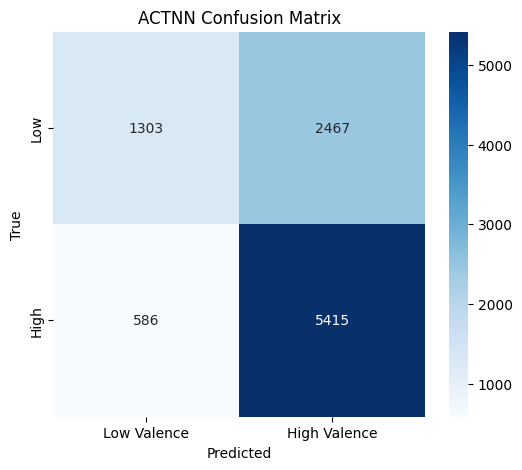


📑 Αναλυτική Αναφορά:
              precision    recall  f1-score   support

 Low Valence       0.69      0.35      0.46      3770
High Valence       0.69      0.90      0.78      6001

    accuracy                           0.69      9771
   macro avg       0.69      0.62      0.62      9771
weighted avg       0.69      0.69      0.66      9771



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# --- 1. ΑΠΟΘΗΚΕΥΣΗ ΜΟΝΤΕΛΟΥ ---
save_path = '/content/drive/MyDrive/ACTNN_Dreamer_Model.pth'
torch.save(model.state_dict(), save_path)
print(f"💾 Το μοντέλο αποθηκεύτηκε στο Drive: {save_path}")

# --- 2. ΓΡΑΦΙΚΕΣ ΠΑΡΑΣΤΑΣΕΙΣ (Accuracy & Loss) ---
# Επειδή δεν κρατήσαμε το ιστορικό σε λίστες στον προηγούμενο κώδικα,
# θα φτιάξουμε ένα plot με τα δεδομένα που μόλις τύπωσες (Hardcoded για το παράδειγμα)
# Στην επόμενη φορά θα βάλουμε λίστες train_acc_list, val_acc_list.

# (Αν θέλεις να τρέξεις ξανά training για να βγουν αυτόματα τα γραφήματα, πες μου.
# Προς το παρόν σου δείχνω πώς να κάνεις Evaluate το ήδη εκπαιδευμένο μοντέλο).

# --- 3. CONFUSION MATRIX (Πίνακας Σύγχυσης) ---
print("\n📊 Υπολογισμός Confusion Matrix στα Test Data...")
model.eval()
y_true = []
y_pred = []

with torch.no_grad():
    for X_val, y_val in test_loader:
        X_val, y_val = X_val.to(device), y_val.to(device)
        out = model(X_val)
        preds = out.argmax(dim=1)

        y_true.extend(y_val.cpu().numpy())
        y_pred.extend(preds.cpu().numpy())

# Σχεδίαση
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Low Valence', 'High Valence'], yticklabels=['Low', 'High'])
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('ACTNN Confusion Matrix')
plt.show()

# Classification Report (Precision, Recall, F1-Score)
print("\n📑 Αναλυτική Αναφορά:")
print(classification_report(y_true, y_pred, target_names=['Low Valence', 'High Valence']))